# 🧠 Entrenamiento del Modelo LSTM para PM2.5
En este notebook cargamos el *Dataset Maestro* (combinación de PostgreSQL y MongoDB), creamos las ventanas temporales (Sliding Windows) y entrenamos un modelo de red neuronal recurrente (LSTM) para predecir el valor de PM2.5 en la próxima hora, usando las 24 horas previas.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuración de rutas
PROJECT_ROOT = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'master_dataset.csv')
MODEL_PATH = os.path.join(PROJECT_ROOT, 'models', 'lstm_pm25.keras')
SCALER_PATH = os.path.join(PROJECT_ROOT, 'models', 'scaler.pkl')

print('Librerías importadas correctamente')


Librerías importadas correctamente


## 1. Carga de Datos y Creación de Ventanas Temporales
Cargamos los datos normalizados que hemos preprocesado previamente.

In [2]:
df = pd.read_csv(DATA_PATH)
df['fecha'] = pd.to_datetime(df['fecha'])
df.set_index('fecha', inplace=True)
print(f'Dimensiones del dataset: {df.shape}')
display(df.head())

Dimensiones del dataset: (50110, 13)


,pm25,no2,o3,temperatura,velocidad_viento,precipitacion,humedad_relativa,hora_del_dia,dia_de_la_semana,pm25_lag1,pm25_lag2,pm25_lag3,pm25_rolling_6h
fecha,,,,,,,,,,,,,
2016-01-01,0.197183,0.408372,0.031746,0.368421,0.08,0.0,0.753247,0.0,0.666667,0.225352,0.239437,0.253521,0.225352
2016-01-01,0.183099,0.448409,0.039683,0.368421,0.08,0.0,0.753247,0.0,0.666667,0.197183,0.225352,0.239437,0.218310
2016-01-01,0.140845,0.512467,0.055556,0.368421,0.08,0.0,0.753247,0.0,0.666667,0.183099,0.197183,0.225352,0.206573
2016-01-01,0.112676,0.360329,0.238095,0.368421,0.08,0.0,0.753247,0.0,0.666667,0.140845,0.183099,0.197183,0.183099
2016-01-01,0.098592,0.288263,0.357143,0.368421,0.08,0.0,0.753247,0.0,0.666667,0.112676,0.140845,0.183099,0.159624


Para entrenar el LSTM, transformamos el DataFrame en tensores 3D `(muestras, pasos_de_tiempo, caracteristicas)`.
Usaremos 24 horas (lags temporales) para predecir la hora siguiente (Target: pm25).

In [3]:
def create_sequences(data, seq_length, target_col_idx):
    xs = []
    ys = []
    # data es un array numpy de (n_samples, n_features)
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length), :]
        y = data[i + seq_length, target_col_idx]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Índice de la columna PM2.5 (asumimos que es la primera, pero verificamos)
target_col_name = 'pm25'
target_idx = df.columns.get_loc(target_col_name)

SEQ_LENGTH = 24 # 24 horas de historia

X, y = create_sequences(df.values, SEQ_LENGTH, target_idx)
print(f'Shape de X (Input): {X.shape}')
print(f'Shape de y (Target): {y.shape}')


Shape de X (Input): (50086, 24, 13)
Shape de y (Target): (50086,)


### División en Train, Validation y Test
Al ser series temporales, **NO** barajamos los datos. Usamos cortes cronológicos (ej: 70% train, 15% val, 15% test).

In [4]:
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f'Train: {X_train.shape}, {y_train.shape}')
print(f'Validation: {X_val.shape}, {y_val.shape}')
print(f'Test: {X_test.shape}, {y_test.shape}')


Train: (35060, 24, 13), (35060,)
Validation: (7512, 24, 13), (7512,)
Test: (7514, 24, 13), (7514,)


## 2. Construcción de la Arquitectura LSTM
Siguiendo la guía preparatoria, usaremos un modelo Keras Secuencial con dos capas LSTM y Dropout.

In [5]:
model = Sequential([
    LSTM(64, activation='relu', input_shape=(SEQ_LENGTH, X.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(1) # Predicción del valor numérico
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()


/Users/miguel/Desktop/Curso IA/Propuesta Proyecto/AirVLCProyecto/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento del Modelo

In [6]:
# Usaremos un número de epochs moderado para iterar rápidamente (ej: 20-30 epochs)
history = model.fit(
    X_train, y_train,
    epochs=10, # Bajar el número de epochs para el test en vivo rápido
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1,
    shuffle=False # IMPORTANTE: En series temporales no mezclamos
)


Epoch 1/10


  1/548 ━━━━━━━━━━━━━━━━━━━━ 8:53 976ms/step - loss: 0.0164 - mae: 0.0934

  9/548 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0125 - mae: 0.0804    

 18/548 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0160 - mae: 0.0933

 26/548 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0172 - mae: 0.0980

...

532/548 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - mae: 0.0526

538/548 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - mae: 0.0527

542/548 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - mae: 0.0527

548/548 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - mae: 0.0527

548/548 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0077 - mae: 0.0563 - val_loss: 0.0025 - val_mae: 0.0321


## 4. Evaluación y Gráficos

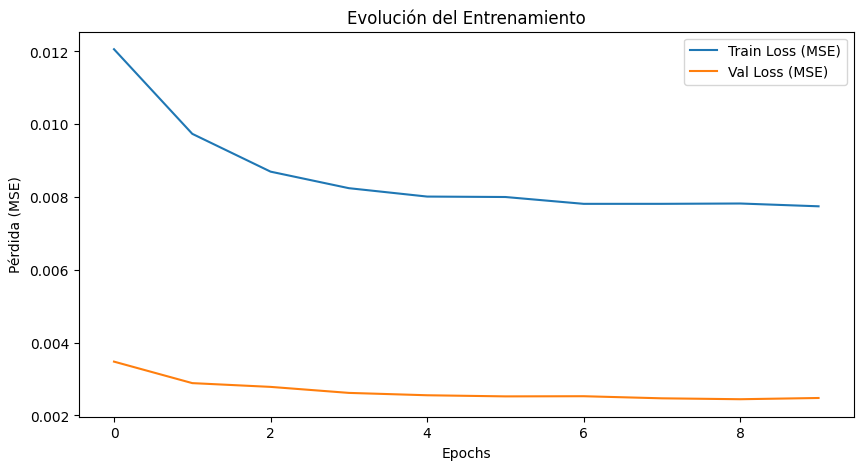

In [7]:
# Evolución del Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Evolución del Entrenamiento')
plt.xlabel('Epochs')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.show()


Hagamos predicciones sobre el conjunto de test y comprobemos qué tal.

  1/235 ━━━━━━━━━━━━━━━━━━━━ 26s 114ms/step

 29/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   

 57/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 86/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

116/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

...

201/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

221/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Test MSE (Scaled): 0.0026
Test MAE (Scaled): 0.0328


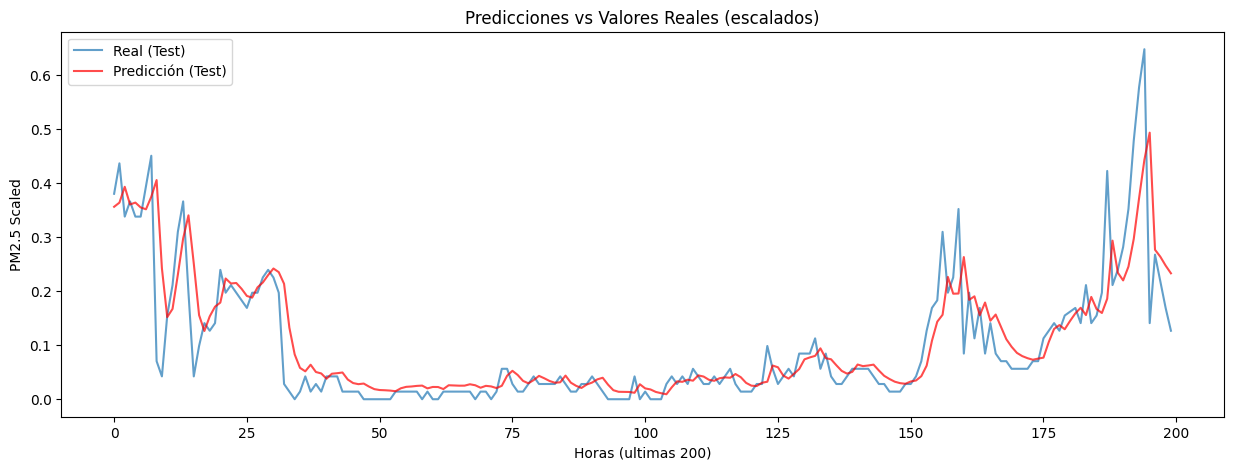

In [8]:
y_pred = model.predict(X_test)

# Métricas (sobre valores escalados)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Test MSE (Scaled): {mse:.4f}')
print(f'Test MAE (Scaled): {mae:.4f}')

# Visualización rápida de una porción (e.g., últimas 100 horas)
plt.figure(figsize=(15, 5))
plt.plot(y_test[-200:], label='Real (Test)', alpha=0.7)
plt.plot(y_pred[-200:], label='Predicción (Test)', color='red', alpha=0.7)
plt.title('Predicciones vs Valores Reales (escalados)')
plt.xlabel('Horas (ultimas 200)')
plt.ylabel('PM2.5 Scaled')
plt.legend()
plt.show()


## 5. Exportación del Modelo

In [9]:
# Guardamos el modelo en el formato Keras v3 (.keras)
model.save(MODEL_PATH)
print(f'✅ Modelo LSTM guardado en: {MODEL_PATH}')


✅ Modelo LSTM guardado en: /Users/miguel/Desktop/Curso IA/Propuesta Proyecto/AirVLCProyecto/models/lstm_pm25.keras
